# HAH913E – Activité physique 00 : ENMO intégré sur des epochs de 10 s (Tania)

- **Dépôt GitHub :** [https://github.com/sarah-mussotte/Physical-activity-00-Project](https://github.com/sarah-mussotte/Physical-activity-00-Project)
- **Membres de l'équipe :** Tania,Thomas,Sarah

## 1. Bibliothèques

On utilise `pandas` pour lire le fichier CSV, `numpy` pour les calculs et `matplotlib` pour les graphiques.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Chargement des données

Le fichier `0_z.csv` contient les données brutes d'un accéléromètre porté au poignet (Axivity AX3) : le temps `t` en secondes et les trois axes `x`, `y`, `z` en g.


In [13]:
def load_data(path):
    """Read the accelerometer CSV file (columns t, x, y, z)."""
    return pd.read_csv(path, comment="#")

data = load_data("0_z.csv")
data.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## 3. Calcul de l'ENMO

L'ENMO (Euclidean Norm Minus One) est la norme du vecteur d'accélération moins 1 g :

$$ENMO = \sqrt{x^2 + y^2 + z^2} - 1$$

Quand le poignet ne bouge pas, l'accéléromètre ne mesure que la gravité : la norme vaut environ 1 g et l'ENMO environ 0.
Soustraire 1 g permet donc d'enlever la gravité et de garder seulement la partie du signal due au mouvement.

In [14]:
def compute_enmo(df):
    """Add an 'enmo' column (in g) to the dataframe."""
    df = df.copy()
    df["enmo"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2) - 1
    return df

data = compute_enmo(data)
data.head()

,t,x,y,z,enmo
0,0.00,-0.0938,-0.0156,0.9531,-0.042168
1,0.02,-0.0938,-0.0156,0.9531,-0.042168
2,0.04,-0.0938,-0.0156,0.9531,-0.042168
3,0.06,-0.0938,-0.0156,0.9531,-0.042168
4,0.08,-0.0938,-0.0156,0.9531,-0.042168


## 4. Intégration de l'ENMO sur des epochs de 10 s

On découpe l'enregistrement en epochs successives de 10 s.
Chaque échantillon est attribué à une epoch avec `t // epoch`, puis on fait la somme de l'ENMO dans chaque epoch.
Cette somme est multipliée par la durée de l'epoch en minutes pour exprimer la valeur intégrée en g.min.
Pour chaque epoch, on garde aussi son temps de début, qui sert à placer la barre sur le graphique.

In [15]:
def integrate_enmo(df, epoch):
    """Integrate ENMO over epochs of `epoch` seconds.
    Returns a dataframe with the epoch start time (s) and the integrated ENMO (g.min)."""
    epoch_index = (df["t"] // epoch).astype(int)
    summed = df.groupby(epoch_index)["enmo"].sum()
    return pd.DataFrame({
        "start": summed.index * epoch,
        "integrated_enmo": summed.values * epoch / 60,
    })

## 5. Graphiques

On trace une figure composée de deux graphiques qui partagent le même axe du temps (en minutes) : ».
- en haut : un diagramme en barres de l'ENMO intégré sur chaque epoch de 10 s,
- en bas : le signal ENMO brut au cours du temps.

Les placer l'un au-dessus de l'autre permet de voir comment chaque barre résume le signal brut de son epoch.

In [16]:
def plot_enmo(df, epoch):
    """Plot integrated ENMO (top) and raw ENMO (bottom) for one epoch length."""
    epochs = integrate_enmo(df, epoch)
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    width = epoch / 60
    ax1.bar(epochs["start"] / 60 + width / 2, epochs["integrated_enmo"],
            width=width * 0.95, color="grey", alpha=0.7)
    ax1.set_title(f"ENMO integrated over {float(epoch)} s intervals")
    ax1.set_ylabel("Integrated ENMO (g.min)")

    ax2.plot(df["t"] / 60, df["enmo"], alpha=0.5)
    ax2.set_title("ENMO over Time")
    ax2.set_xlabel("Time (minutes)")
    ax2.set_ylabel("ENMO (g)")

    plt.show()

## 6. Résultat pour des epochs de 10 s

On appelle la fonction de tracé avec une durée d'epoch de 10 s.
Avec des epochs courtes, on obtient beaucoup de barres : le graphique garde plus de détails sur le moment où le mouvement a eu lieu.

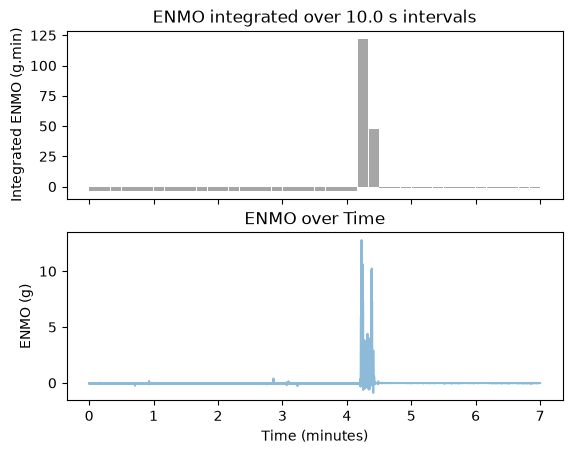

In [17]:
plot_enmo(data, 10)

## 7. Prompts Copilot et modifications (Tania)

| Prompt utilisé | Suggestion obtenue | Ce que j'ai modifié après relecture |
|---|---|---|
| Write a Python function that computes ENMO from x, y, z columns of a pandas dataframe | Copilot a repéré que le notebook contenait déjà une fonction `compute_enmo` et a proposé presque le même code : norme de (x, y, z) moins 1, sur une copie du dataframe (variable `result` au lieu de `df`). | Rien : sa proposition était équivalente à mon code, j'ai gardé ma version. |
| Write a function that integrates ENMO over 10 second epochs | Copilot a vu que les mesures sont espacées de 0,02 s (50 Hz) et a proposé une nouvelle fonction qui multiplie la somme de l'ENMO de chaque epoch par cet intervalle (et non par la durée de l'epoch), en disant que mon multiplicateur surestimait l'intégrale. Il l'a ajoutée dans une nouvelle cellule et a voulu l'exécuter. | J'ai refusé l'exécution et annulé sa cellule (Undo). Sa méthode donne des valeurs 500 fois plus petites (environ 0,25 au lieu de 122 g.min pour le pic), qui ne correspondent pas aux graphiques de référence de la consigne. J'ai donc gardé ma fonction `integrate_enmo` pour obtenir les mêmes graphiques que ceux demandés. |
### Utilisation de Claude (Anthropic)

J'ai utilisé Claude pour m'aider à écrire le code du notebook, puis je lui ai posé des questions pour comprendre les choix faits dans chaque fonction.

| Prompt utilisé | Réponse obtenue | Ce que j'ai vérifié ou retenu |
|---|---|---|
| Dans `compute_enmo`, pourquoi faire `df.copy()` avant d'ajouter la colonne `enmo`, au lieu de modifier directement le dataframe ? | `copy()` évite de modifier le dataframe d'origine : la fonction renvoie un nouveau tableau sans effet de bord. | J'ai gardé `copy()` : on peut relancer les cellules sans modifier les données de départ. |
| Dans `integrate_enmo`, que fait exactement `(df["t"] // epoch).astype(int)`, et pourquoi utiliser `groupby` plutôt qu'une boucle `for` ? | La division entière donne le numéro d'epoch de chaque mesure (ex. `23.4 // 10 = 2`) ; `groupby` fait toutes les sommes d'un coup, sans gérer les bornes à la main. | J'ai vérifié avec `data.groupby((data["t"] // 10).astype(int)).size()` que chaque epoch de 10 s contient bien 500 mesures (50 Hz × 10 s). |
| Dans `plot_enmo`, à quoi sert `sharex=True`, et pourquoi décale-t-on les barres de `width / 2` ? | `sharex=True` aligne les deux graphiques sur le même axe du temps ; `ax.bar()` centre les barres, donc on décale d'une demi-largeur pour que chaque barre couvre son epoch. | J'ai vérifié sur mon graphique que la barre du pic est bien alignée avec le mouvement visible sur la courbe du bas, vers 4 min. |